In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2


import microns_datacleaner as mic

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Getting anatomical and functional data of neurons 

In [126]:
import microns_datacleaner.filters as fl

In [127]:
cleaner = mic.MicronsDataCleaner(datadir="data/", version=1718)

units, segments = cleaner.process_nucleus_data(functional_data='best_only')

Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 109602.48it/s]


In [128]:
units

,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90429,167679,864691135783968051,427.922269,496.375161,1005.96,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90430,303490,864691136298957339,668.626983,461.348673,1003.64,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90431,233088,864691135430122800,533.829149,454.887682,1007.28,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90432,232979,864691135527904347,519.002564,451.791678,986.64,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5


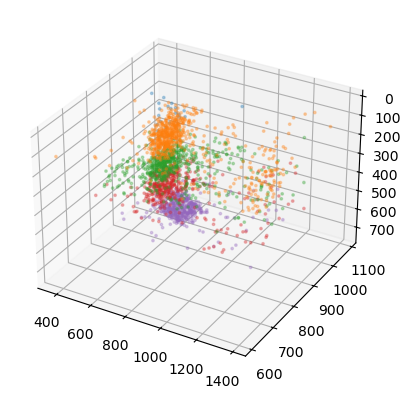

In [129]:
fig = plt.figure()
ax  = fig.add_subplot(projection='3d')

ax.zaxis.set_inverted(True)

for layer in ['L1', 'L2/3', 'L4', 'L5', 'L6']:
    ulayer = fl.filter_neurons(units, layer=layer, proofread='ax_clean') 
    ax.scatter(ulayer['pt_position_x'], ulayer['pt_position_z'], ulayer['pt_position_y'], alpha=0.3, s=3)

plt.show()

In [141]:
ulayer = units[units['classification_system']=='excitatory_neuron']
ulayer

,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
3,200523,864691135777840480,513.635721,509.463386,652.56,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
4,372649,864691136273924109,829.039163,557.615841,1039.92,excitatory_neuron,6P-IT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
5,372421,864691135281043105,828.733386,580.203143,960.36,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90429,167679,864691135783968051,427.922269,496.375161,1005.96,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90430,303490,864691136298957339,668.626983,461.348673,1003.64,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90431,233088,864691135430122800,533.829149,454.887682,1007.28,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5
90432,232979,864691135527904347,519.002564,451.791678,986.64,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5


In [6]:
pre_neurons  = fl.filter_neurons(units, layer='L2/3', brain_area='V1', proofread='ax_clean', tuning='matched')
post_neurons = fl.filter_neurons(units, layer='L2/3', brain_area='V1', tuning='matched')

post_neurons

,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
16,189115,864691135738006641,501.233729,104.152149,960.08,excitatory_neuron,23P,V1,none,none,6.0,2.0,2184.0,33.797482,213.797482,0.359622,0.023755,0.373394,matched,L2/3
20,153275,864691135463256477,476.232006,135.114928,804.24,excitatory_neuron,23P,V1,none,none,6.0,2.0,1890.0,101.958986,101.958986,0.062396,0.056385,0.563241,matched,L2/3
21,153085,864691135748985641,475.434732,106.777609,743.60,excitatory_neuron,23P,V1,none,none,6.0,7.0,1525.0,114.008709,294.008709,0.125745,0.069892,0.344436,matched,L2/3
53,391162,864691135786545860,934.742316,188.014032,898.56,excitatory_neuron,23P,V1,none,none,9.0,6.0,4437.0,100.699472,280.699472,0.243642,0.074305,0.418179,matched,L2/3
57,390337,864691135156852068,895.572178,134.926114,688.92,excitatory_neuron,23P,V1,none,none,5.0,7.0,2349.0,145.315123,325.315123,0.152421,0.054205,0.123420,matched,L2/3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89796,256529,864691135102274592,650.922627,107.097605,847.36,excitatory_neuron,23P,V1,axon_partially_extended,dendrite_clean,6.0,4.0,2014.0,72.377748,72.377748,0.421845,0.182214,0.435281,matched,L2/3
89842,452497,864691135976467523,1023.994626,93.095690,822.16,excitatory_neuron,23P,V1,none,none,6.0,7.0,956.0,80.848777,260.848777,0.173099,0.024549,0.288042,matched,L2/3
89850,360127,864691136924796900,818.004496,130.067155,1048.28,excitatory_neuron,23P,V1,none,none,9.0,4.0,5123.0,59.162324,239.162324,0.202580,0.042669,0.421977,matched,L2/3
89924,421011,864691135279141793,949.253269,116.880058,1005.20,excitatory_neuron,23P,V1,none,none,9.0,4.0,1748.0,6.020927,6.020927,0.309806,0.038921,0.714675,matched,L2/3


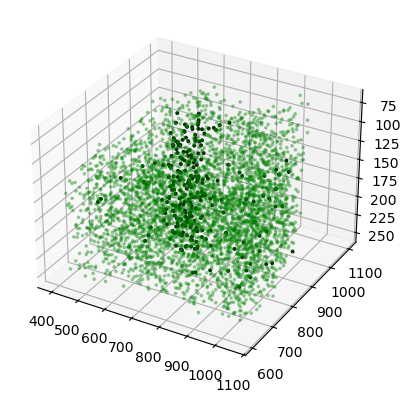

In [7]:
fig = plt.figure()
ax  = fig.add_subplot(projection='3d')

ax.zaxis.set_inverted(True)

ax.scatter(post_neurons['pt_position_x'], post_neurons['pt_position_z'], post_neurons['pt_position_y'], alpha=0.3, s=3, color='green')
ax.scatter(pre_neurons['pt_position_x'], pre_neurons['pt_position_z'], pre_neurons['pt_position_y'], alpha=1.0, s=3, color='black')

plt.show()

In [8]:
#cleaner.download_synapse_data(pre_neurons['pt_root_id'], post_neurons['pt_root_id'])
cleaner.merge_synapses("synapses_L23")

In [9]:
connections = pd.read_csv("data/1718/raw/synapses_L23.csv")
connections

,pre_pt_root_id,post_pt_root_id,size
0,864691134919972106,864691134919972106,5712
1,864691134919972106,864691134965735199,1632
2,864691134919972106,864691135726520639,2228
3,864691134919972106,864691136011300782,2944
4,864691134941412707,864691135277186789,5724
...,...,...,...
12019,864691137198691137,864691135656477378,14072
12020,864691137198691137,864691135778638013,9524
12021,864691137198691137,864691136013466787,27568
12022,864691137198691137,864691136067669912,19384


In [10]:
connections["post_pt_root_id"].unique().shape

(3212,)

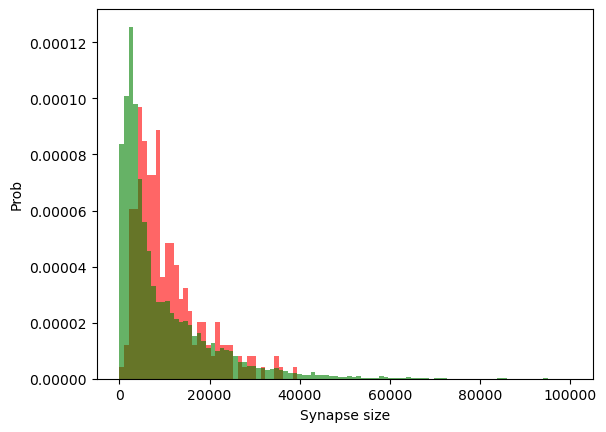

In [11]:
autapses = connections[connections['pre_pt_root_id'] == connections['post_pt_root_id']]
synapses = connections[connections['pre_pt_root_id'] != connections['post_pt_root_id']]

bins = np.linspace(0, 1e5, 100)
plt.hist(autapses['size'], bins=bins, alpha = 0.6, density=True, color='red')
plt.hist(synapses['size'], bins=bins, alpha = 0.6, density=True, color='green')
plt.xlabel('Synapse size')
plt.ylabel('Prob')
plt.show()

In [12]:
synapses['size'] = synapses['size'] / synapses['size'].mean()

/tmp/ipykernel_7975/2580813160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapses['size'] = synapses['size'] / synapses['size'].mean()


In [13]:
units = units.set_index('pt_root_id')
synapses['distance'] = (units.loc[synapses['pre_pt_root_id'], 'pt_position_x'].values - units.loc[synapses['post_pt_root_id'], 'pt_position_x'].values)**2 +  \
(units.loc[synapses['pre_pt_root_id'], 'pt_position_y'].values - units.loc[synapses['post_pt_root_id'], 'pt_position_y'].values)**2 +  \
(units.loc[synapses['pre_pt_root_id'], 'pt_position_z'].values - units.loc[synapses['post_pt_root_id'], 'pt_position_z'].values)**2   

synapses['distance'] = np.sqrt(synapses['distance'])
synapses

/tmp/ipykernel_7975/3485250680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapses['distance'] = (units.loc[synapses['pre_pt_root_id'], 'pt_position_x'].values - units.loc[synapses['post_pt_root_id'], 'pt_position_x'].values)**2 +  \
/tmp/ipykernel_7975/3485250680.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapses['distance'] = np.sqrt(synapses['distance'])


,pre_pt_root_id,post_pt_root_id,size,distance
1,864691134919972106,864691134965735199,0.173027,81.990551
2,864691134919972106,864691135726520639,0.236216,98.381891
3,864691134919972106,864691136011300782,0.312127,47.360774
4,864691134941412707,864691135277186789,0.606867,98.783713
5,864691134941412707,864691135280988577,0.396520,74.162505
...,...,...,...,...
12019,864691137198691137,864691135656477378,1.491935,53.488123
12020,864691137198691137,864691135778638013,1.009749,126.749743
12021,864691137198691137,864691136013466787,2.922801,141.728038
12022,864691137198691137,864691136067669912,2.055121,137.666158


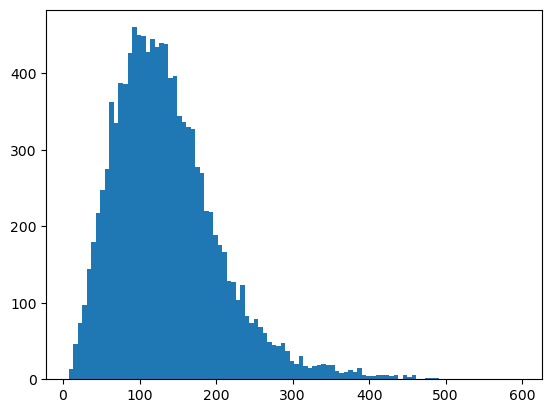

In [14]:
plt.hist(synapses['distance'], bins=100)
plt.show()

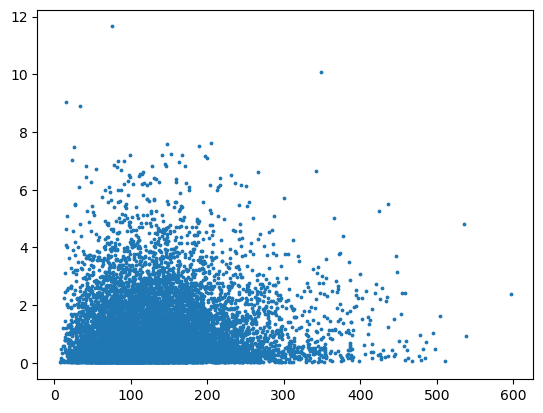

In [15]:
plt.scatter(synapses['distance'], synapses['size'], s = 3)

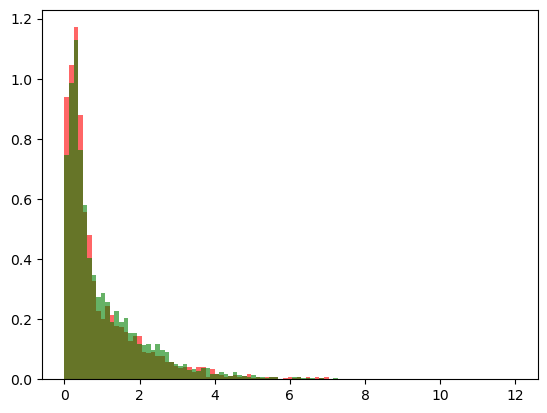

In [16]:
mask = synapses['distance'] < 100. 
size_close = synapses.loc[mask, 'size'].values
size_far   = synapses.loc[~mask, 'size'].values


bins = np.linspace(0, 12, 100)
plt.hist(size_close, bins=bins, alpha = 0.6, density=True, color='red')
plt.hist(size_far, bins=bins, alpha = 0.6, density=True, color='green')
plt.show()

In [17]:
units = units.reset_index()

# Let's construct filters for the neurons

The idea is to model the neuron response as a Gabor kernel $D(\vec x,\vec c, \theta, \phi, k, \alpha, \beta) \equiv D_p(\vec x)$ where $\vec x$ is the position on the screen; $\vec c$ is the center of the Gabor kernel; $\theta$ the orientation, $\phi$ the phase shift, $k$ is the spatial frequency, and $\alpha,\beta$ parameters of the Gaussian controlling size and eccentricity of the Gabor. The Gabor filters have functional shape

$$
D_p (\vec x) = \cos(2\pi f \vec u \cdot \vec x + \phi) \exp \left(   -\frac{(\vec x \cdot \vec u)^2 +\beta (\vec x \cdot \vec v)^2}{2\alpha^2}    \right)
$$

where we have written $\vec k = 2\pi f \vec u$ and selected $v$ to be a vector perpendicular to $u$. If we know the filter associated to a neuron, given an image $I_j(\vec x)$ we will have that the response of the $i$th neuron is 

$$
r_{ij} = \int d\vec x D_{p(i)} (\vec x, \vec p) I_j(\vec x)
$$

The idea is to fit the parameters $p(i)$ of the $i$-th neuron to obtain $D(\vec x, \vec p)$. To do so we generate the Gabor filters for a large array of parameter combinations, and compute the response for each proposed gabor filter.  We will need to check which neurons are simple or complex cells, for which we study the linear combination

$$
\bar r_{ij} = c_1 |r_{ij}|_+ + c_2 \sqrt{\frac{r_{ij}^2(\phi) + r_{ij} ^2 (\phi + \pi/2) }{2}} 
$$

where $|\cdot|_+$ is the ReLu nonlinearity and the second term is the geometric average of the fit and the same fit with a shift in phase -simple and complex cells differ only in their behaviour with respect to phase. $c_1$ and $c_2$ are obtained by simple linear regression. At the end, we choose the set of parameters $p$ that minimizes the loss $(\bar r_{ij} - r_{ij}^\text{obs})^2$ where $r_{ij} ^\text{obs}$ are the observed responses from the experiments.

Once we have the responses of the neuron to all images, it is possible to predict the neuron response as a function of the spatial frequency by constructing gratings

$$
G(\vec x, \vec k) = \cos(2\pi \vec k \cdot \vec x) 
$$

and computing

$$
r_i(\vec k) = \int d\vec x  D_{p(i)}(\vec x) G(\vec x, \vec k)
$$

In [18]:
import scipy.fft as sft

In [19]:
#Get all neurons at a particular session, sort them by best fit according to Microns' digital twin model
units = units.reset_index()
units[(units['session']==9) & (units['scan_idx']==4)].sort_values(by='cc_abs')

,index,pt_root_id,nucleus_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,...,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
51970,51970,864691136813611886,292231,705.937893,166.325882,695.72,excitatory_neuron,23P,V1,none,...,9.0,4.0,7525.0,116.699471,116.699471,0.305546,0.126190,-0.011753,matched,L2/3
89356,89356,864691135940356518,608829,1356.303559,113.238973,1006.16,excitatory_neuron,23P,RL,none,...,9.0,4.0,1447.0,102.051232,102.051232,0.096268,0.113040,0.001392,matched,L2/3
48643,48643,864691136051917299,422245,992.847977,159.048050,869.12,excitatory_neuron,23P,V1,none,...,9.0,4.0,7319.0,83.522350,83.522350,0.112480,0.129676,0.027631,matched,L2/3
68254,68254,864691135700498466,518080,1144.090238,170.673921,737.04,excitatory_neuron,23P,RL,none,...,9.0,4.0,7173.0,91.814768,91.814768,0.049182,0.069433,0.031363,matched,L2/3
23577,23577,864691135448105106,292993,740.486351,136.391068,915.40,excitatory_neuron,23P,V1,none,...,9.0,4.0,5499.0,93.150753,273.150753,0.161008,0.066293,0.033009,matched,L2/3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15603,15603,864691135975478127,422120,972.162214,159.037125,834.96,excitatory_neuron,23P,V1,none,...,9.0,4.0,5369.0,87.152458,267.152458,0.219216,0.152365,0.795418,matched,L2/3
87617,87617,864691135839563667,222983,578.454364,146.756493,926.00,excitatory_neuron,23P,V1,none,...,9.0,4.0,4847.0,85.804288,265.804288,0.248614,0.164720,0.813572,matched,L2/3
43831,43831,864691135582655597,390776,924.400099,176.251890,777.40,excitatory_neuron,23P,V1,none,...,9.0,4.0,8129.0,72.027518,252.027518,0.306638,0.061650,0.839871,matched,L2/3
20929,20929,864691136101564789,358904,833.525668,172.220320,718.36,excitatory_neuron,23P,V1,none,...,9.0,4.0,8061.0,89.830463,269.830463,0.473619,0.163979,0.863554,matched,L2/3


### Construct the Gabor filters...

In [20]:
funcreader = mic.MicronsFunctionalReader(datadir="../../../../Research/Milan/MICrONS-datacleaner/data/")

We need to get all the trials that are of the Trippy type. There's no automatic way to do it, so we go through all hashes and check the type.

In [21]:
#Get the hashes for the videos in this session
hashes  = funcreader.get_hashes_by_session("9_4")

trippy_trials = []
for h in hashes:
    stim_type = funcreader.get_video_type(h)
    if stim_type == 'Trippy':
        trippy_trials.append(h)

video = funcreader.get_video_data(trippy_trials[0])

In [22]:
funcreader.get_responses_by_hash(trippy_trials[0], "V1")

[{'session': '9_4',
  'trial_idx': '9_4_tr10',
  'responses': array([[4.87045071e-08, 8.11954877e-08, 6.35437573e-07, ...,
          1.01303455e-08, 7.13731252e-09, 6.63424871e-09],
         [3.43658738e-02, 5.87338569e-08, 9.84456534e-08, ...,
          3.25485972e-09, 3.94469657e-09, 9.29552080e-09],
         [5.74900199e-08, 6.40242988e-08, 6.77122003e-08, ...,
          7.03215193e-08, 6.82491503e-08, 7.05697047e-08],
         ...,
         [7.81426549e-01, 8.66062790e-02, 8.77159715e-01, ...,
          2.89524650e-07, 5.24759173e-07, 1.44073629e+01],
         [3.61975694e-08, 8.17257941e-08, 1.09788532e+01, ...,
          7.40935604e-07, 7.49741247e-08, 1.17710250e-07],
         [5.50919609e+01, 2.65503330e+01, 1.52895936e-08, ...,
          1.25475101e+01, 2.81626625e+01, 3.75451776e-08]],
        shape=(5928, 113), dtype=float32)},
 {'session': '9_4',
  'trial_idx': '9_4_tr242',
  'responses': array([[2.3167571e-08, 2.2456419e-08, 2.5133881e-08, ..., 1.6694278e+00,
          8.2

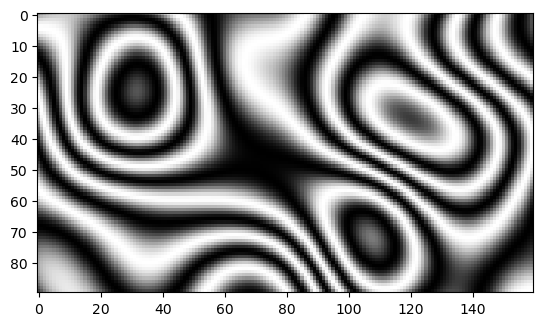

In [23]:
#Check the video
width = video['clip'].shape[1]
height = video['clip'].shape[2]

plt.imshow(video['clip'][0,:,:], cmap='gray')

Now we start some important auxiliary functions to create the Gabor functions. These get the parallel and perpendicular vectors according to the orientation direction, spatial frequency, and precompute some factors.  

In [24]:
#Return k, u, v, phi, alfa2, beta for the nxt function
def prepare_pars(f, theta, phi, alfa, beta):
    return 2*np.pi*f, np.array([np.cos(theta), np.sin(theta)]), np.array([np.sin(theta), -np.cos(theta)]), phi, -1/(2*alfa**2), beta

#Auxiliary functions to get the u and v functions
def getuv(theta):
    return np.array([np.cos(theta), np.sin(theta)]), np.array([np.sin(theta), -np.cos(theta)])

#Centered at 0,0, call as x-c to center somewhere else.
#x needs to be a 2D vector
def gabor(x, k, u, v, phi, invalfa2, beta, scale=1.0):
    g = np.cos(k*np.dot(x,u) + phi) * np.exp(invalfa2*(np.dot(x,u)**2 + beta*np.dot(x,v)**2 )) 
    g -= g.mean()
    return scale * g / np.sqrt(np.sum(g**2))


In [25]:
#Get all the pairs of pixels where our function needs to be computed
xp, yp = np.meshgrid(np.arange(0,width), np.arange(0,height), indexing='ij')
allpixels = np.column_stack((xp.ravel(), yp.ravel()))
xp, yp = None, None

In [26]:
#Example gabor for some parameters...
f = 0.1
theta = 70.0
phi = 0.
alfa = 4.
beta = 2.

c = np.array([20,40])
k, u, v, phi, invalfa2, beta = prepare_pars(f, theta, phi, alfa, beta) 
g = gabor(allpixels-c, k, u, v, phi, invalfa2, beta)
g = g.reshape(width, height)

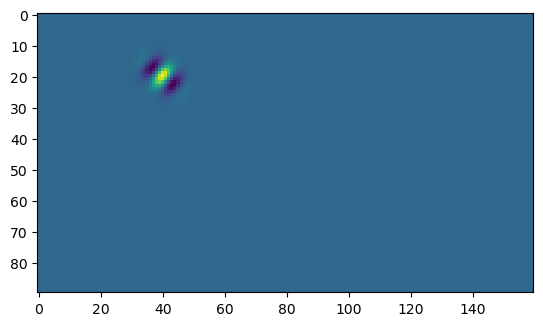

In [27]:
plt.imshow(g)

### Obtain the Fourier transform of images and gabors

The response to an image is given by integrating the gabor with the image. In practice, we will generate a batch of gabors with all possible parameters $p$ and compute their responses to each image. Then we will be able to optimize the best ones. 

One of the parameters is the gabor center $\vec c$. This parameter can be written so we have the gabor at the origin and we offset it, getting the response at the selected center

$$
r_{ij} (\vec c) = \int d\vec x  D_{p(i)}(\vec x - \vec c) I_j (\vec x) = D_{p(i)}(-\vec x) * I_j (\vec x)
$$

This is a convolution. Therefore, if we Fourier transform both functions, it means that the integral can be written as the product of those Fourier transforms

$$
r_{ij} (\vec c) = \mathcal F ^{-1} \left( \hat D_{p(i)}(-\vec \omega)  I_j (\vec \omega) \right)
$$

The Fourier Transform of the images can be precomputed, or even got analytically.

In [28]:
hatg = np.abs(sft.fft2(g))

#Important! fftshift is only for normalization
omegax = sft.fftshift(sft.fftfreq(width, 1))
omegay = sft.fftshift(sft.fftfreq(height, 1))

hatg = sft.fftshift(hatg)

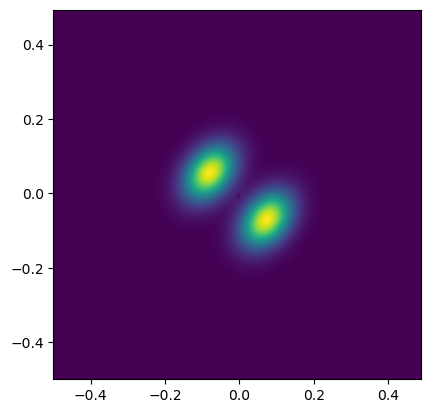

In [29]:
plt.imshow(hatg, extent=[omegax[0], omegax[-1], omegay[0], omegay[-1]], interpolation='gaussian')

The next step is to check that we can recover the results at any center, in comparison with a direct integral

In [30]:
from matplotlib.patches import Circle

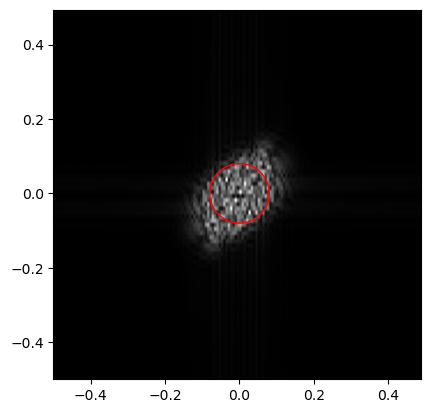

In [31]:
#Substract mean is ONLY for visualization purposes to kill the central component
fftvid = np.abs(sft.fft2(video['clip'][0,:,:] - video['clip'][0,:,:].mean()))  
fftvid = sft.fftshift(fftvid) 
fig, ax = plt.subplots()
ax.imshow(fftvid, extent=[omegax[0], omegax[-1], omegay[0], omegay[-1]], cmap='gray')

circle = Circle((0,0), video['spatial_freq'], fill=False, color='red')
ax.add_patch(circle)
plt.show()

In [32]:
#O
omegax = sft.fftfreq(width, 1)
omegay = sft.fftfreq(height, 1)

wxp, wyp = np.meshgrid(omegax, omegay, indexing='ij')
allomegas = 2*np.pi*np.column_stack((wxp.ravel(), wyp.ravel()))

wxp, wyp = None, None

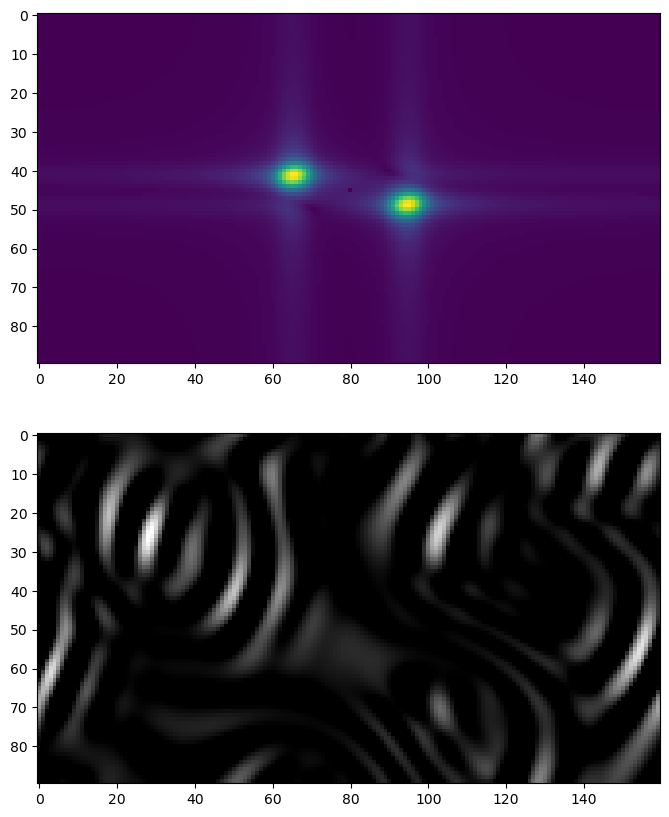

In [55]:
#Take another example Gabor
#Parameters...
f = 0.1
theta = 20.0
phi = 0.
alfa = 12.
beta = 2. 
k, u, v, phi, invalfa2, beta = prepare_pars(f, theta, phi, alfa, beta) 

#Make the Gabor
g = gabor(allpixels, k, u, v, phi, invalfa2, beta)
g = g.reshape(width, height)
hatg = sft.fft2(g)

#Fourier transform the video
fftvid = sft.fft2(video['clip'][0,:,:]) 

#Compute the response
response = np.real(sft.ifft2(hatg * fftvid))
response = np.maximum(0, response)

f, axes = plt.subplots(nrows=2, figsize=(12, 10))

#Shift just for plotting!
plot_hatg = sft.fftshift(hatg)
axes[0].imshow(np.abs(plot_hatg))
axes[1].imshow(response, cmap='gray')

plt.show()

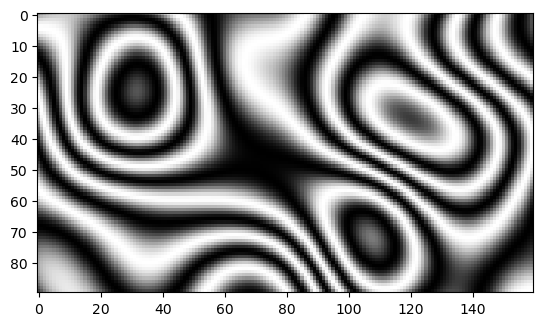

In [34]:
plt.imshow(video['clip'][0,:,:], cmap='gray') 

### Open the data and create training + test sets

In [35]:
funcreader = mic.MicronsFunctionalReader(datadir="../../../../Research/Milan/MICrONS-datacleaner/data/")

In [36]:
hashes  = funcreader.get_hashes_by_session("9_4")

In [37]:
#Get all trials of the Trippy stimulus and the corresponding video hashes 
trippy_trials = []
trippy_hashes = []
for trial, h in enumerate(hashes):
    stim_type = funcreader.get_video_type(h)
    if stim_type == 'Trippy':
        trippy_hashes.append(h)
        trippy_trials.append(trial)

In [38]:
video = funcreader.get_video_data(trippy_hashes[0])
n_frames_trippy = video['clip'].shape[0]

In [39]:
#Number of frames to use, training and test!
frames_training = 100 
frames_test     = 100 

#These two tell us the exact frame we will be taking from a trial
r_seed = 1238198732
np.random.seed(r_seed)
selected_trials = np.random.choice(trippy_trials, size=frames_training)
selected_frames = np.random.choice(n_frames_trippy, size=frames_training)
labels = zip(selected_trials, selected_frames)

#Get the responses at the given trial and frame
target_response = np.zeros(frames_training)
neuron_id = 7685
for i,(t,f) in enumerate(labels): 
    r = funcreader.get_trial("9_4", t)
    target_response[i] = r['responses'][neuron_id, f]

#Same, but with tests
test_trials = np.random.choice(trippy_trials, size=frames_test)
test_frames = np.random.choice(n_frames_trippy, size=frames_test)
labels = zip(test_trials, test_frames )

neuron_id = 7685
test_response = np.zeros(frames_test)
for i,(t,f) in enumerate(labels): 
    r = funcreader.get_trial("9_4", t)
    test_response[i] = r['responses'][neuron_id, f]


### Integrate with a video to obtain responses 

Next step: define a grid of parameters and go over all of those. The centers will not be in the parameters, as they are the parameter emerging when taking the inverse Fourier transform before

In [107]:
npars = {}

npars['ori']     = 7 
npars['spatial'] = 5 
npars['shift']   = 4
npars['alpha']   = 5 
npars['beta']    = 4


parspace = {}
parspace['ori']     = np.linspace(0, np.pi, npars["ori"], endpoint=False) 
parspace['spatial'] = np.linspace(0.01, 0.13, npars["spatial"]) 
parspace['shift']   = np.linspace(0, 2*np.pi, npars["shift"], endpoint=False)
parspace['alpha']   = np.linspace(1, 12, npars["alpha"]) 
parspace['beta']    = np.linspace(1, 2.5, npars["beta"])
parspace['cx']      = np.arange(0, width, 30)
parspace['cy']      = np.arange(0, width, 40)

npars['cx']  = len(parspace['cx'])
npars['cy']  = len(parspace['cy'])

error_responses = np.zeros((npars['ori'], npars['spatial'], npars['shift'], npars['alpha'], npars['beta'], npars['cx'], npars['cy']))
npars['total'] = error_responses.size 
npars['total']

25200

In [108]:
#Mask to get the response at the given centers after the convolution
cx, cy = np.meshgrid(parspace['cx'], parspace['cy'], indexing='ij')

In [109]:
#This function computes the response to each gabor, for all possible combinations of parameters
def find_optimal_gabor(width, height, npars, parspace, nframes, target):

    #Initialize
    error_responses = np.zeros((npars['ori'], npars['spatial'], npars['shift'], npars['alpha'], npars['beta'], npars['cx'], npars['cy']))

    #Grid all the pixels
    xp, yp = np.meshgrid(np.arange(0,width), np.arange(0,height), indexing='ij')
    allpixels = np.column_stack((xp.ravel(), yp.ravel()))
    xp, yp = None, None

    #Response to several frames...
    for trial_idx in range(nframes): 
        #Get the selected frame from the adequate trial
        strial = selected_trials[trial_idx]
        sframe = selected_frames[trial_idx]

        #Get the hash corresponding to our trial and use it to retrieve the video 
        trial_hash = hashes[strial]
        video = funcreader.get_video_data(trial_hash)
        fftvid = sft.fft2(video['clip'][sframe, :, :])

        #The most beautiful loop in the world
        for i1,theta in enumerate(parspace["ori"]):
            u,v = getuv(theta)

            for i2,f in enumerate(parspace["spatial"]):
                k = 2*np.pi*f

                for i3,phi in enumerate(parspace["shift"]):
                    for i4,alfa in enumerate(parspace["alpha"]):
                        invalfa2 = -1/(2*alfa**2),

                        for i5,beta in enumerate(parspace["beta"]):

                            #For this combination of paramters, compute the gabor and FFT
                            #Scale was set by hand!
                            g = gabor(allpixels, k, u, v, phi, invalfa2, beta, scale=0.03)
                            g = g.reshape(width, height)
                            hatg = sft.fft2(g)

                            #Get the response to this video from this gabor
                            r = np.real(sft.ifft2(hatg * fftvid))
                            r = np.maximum(0, r)
                            #Get the response at the selected centers
                            #note cx, cy are arrays so r is a 2D array
                            r = r[cx, cy]

                            #Add the error from the observed response from this trial
                            #The last two [...:, :] are because r is a 2D array 
                            error_responses[i1, i2, i3, i4, i5, :, :] += (r - target[trial_idx])**2
    

    #Get the minimum of the error across all responses
    imin = np.argmin(error_responses)
    imin = np.unravel_index(imin, error_responses.shape)
    fit_pars_gabor = [parspace['ori'][imin[0]], parspace['spatial'][imin[1]], parspace['shift'][imin[2]], parspace['alpha'][imin[3]], parspace['beta'][imin[4]], 
                    parspace['cx'][imin[5]], parspace['cy'][imin[6]]]

    #Put them in a legible way
    c = np.zeros(2)
    theta, f, phi, alfa, beta, c[0], c[1] = fit_pars_gabor

    #Get the optimal gabor
    k, u, v, phi, invalfa2, beta = prepare_pars(f, theta, phi, alfa, beta) 
    g = gabor(allpixels-c, k, u, v, phi, invalfa2, beta, scale=0.03)
    g = g.reshape(width, height)

    #Return gabor and its parameters
    return g, fit_pars_gabor

In [110]:
g, fit_pars_gabor = find_optimal_gabor(width, height, npars, parspace, frames_training, target_response)
fit_pars_gabor

[np.float64(2.243994752564138),
 np.float64(0.13),
 np.float64(1.5707963267948966),
 np.float64(1.0),
 np.float64(2.5),
 np.int64(60),
 np.int64(40)]

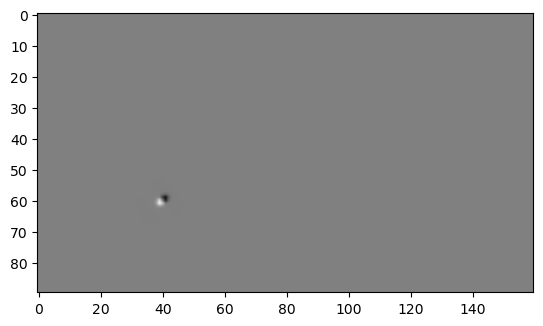

In [111]:
hatg = sft.fft2(g)

plt.imshow(g, interpolation='gaussian', cmap='gray')

Let's try to a shuffled control: we take all the responses and shuffle them, so they don't correspond to their video frames anymore, and then get the optimal Gabor for this set. This should have a larger error when predicting responses.

In [112]:
shuffled_responses = target_response.copy()
np.random.shuffle(shuffled_responses)

gcontrol, fit_pars_control = find_optimal_gabor(width, height, npars, parspace, frames_training, shuffled_responses)
fit_pars_control

[np.float64(2.243994752564138),
 np.float64(0.13),
 np.float64(1.5707963267948966),
 np.float64(1.0),
 np.float64(2.5),
 np.int64(30),
 np.int64(40)]

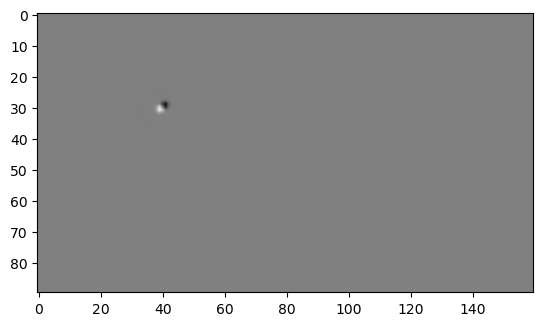

In [113]:
hatgcontrol = sft.fft2(gcontrol)

plt.imshow(gcontrol, interpolation='gaussian', cmap='gray')

In [114]:
#Take the Fourier transform of the Gabor on the given trials, frames and label response
def evaluate_error(hatg, nframes, trials, frames, response):
    error = np.zeros(nframes)
    
    #Evaluate the gabor on the given frames
    for trial_idx in range(nframes): 
        #Get the selected frame
        strial = trials[trial_idx]
        sframe = frames[trial_idx]
        trial_hash = hashes[strial]

        video = funcreader.get_video_data(trial_hash)
        fftvid = sft.fft2(video['clip'][sframe, :, :])

        r = np.real(sft.ifft2(hatg * fftvid))
        r = np.maximum(0, r)

        #The last 2 parameters are the center of the gabor
        r = r[fit_pars_gabor[-2], fit_pars_gabor[-1]]

        error[trial_idx] = (r - response[trial_idx])**2
    
    return error

In [115]:
#Errors on training and test
error_train = evaluate_error(hatg, frames_training, selected_trials, selected_frames, target_response)
error_test  = evaluate_error(hatg, frames_test, test_trials, test_frames, test_response)

#Error using the control gabor
error_control_train = evaluate_error(hatgcontrol, frames_training, selected_trials, selected_frames, target_response)
error_control_test  = evaluate_error(hatgcontrol, frames_test, test_trials, test_frames, test_response)

#Error assuming all responses are 0
error_zeros_train = evaluate_error(hatg, frames_training, selected_trials, selected_frames, np.zeros(len(target_response)))
error_zeros_test  = evaluate_error(hatg, frames_test, test_trials, test_frames, np.zeros(len(test_response)))

{'bodies': [<matplotlib.collections.PolyCollection at 0x7f5d7606ded0>,
 'cmeans': <matplotlib.collections.LineCollection at 0x7f5d76089250>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f5d7554e1d0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f5d75567dd0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f5d75ffe550>}

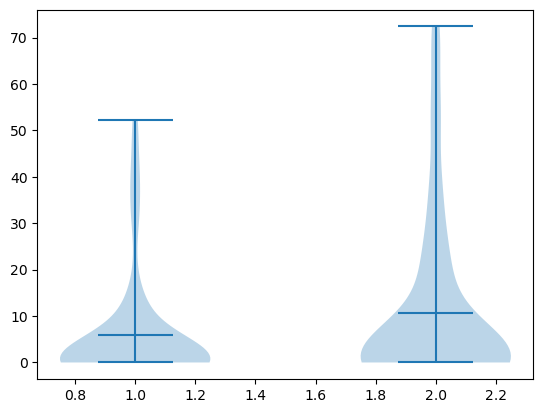

In [116]:
plt.violinplot([error_train, error_control_train], showmeans=True)

In [117]:
from scipy.stats import wilcoxon, ttest_ind

In [118]:
wilco_train = wilcoxon(error_train, error_control_train, alternative='less')
t_train     = ttest_ind(error_train, error_control_train, alternative='less')

wilco_train.pvalue < 0.05, t_train.pvalue < 0.05

(np.True_, np.True_)

{'bodies': [<matplotlib.collections.PolyCollection at 0x7f5d76b2ee90>,
 'cmeans': <matplotlib.collections.LineCollection at 0x7f5d7606e650>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f5d75520e50>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f5d760d0950>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f5d7617a190>}

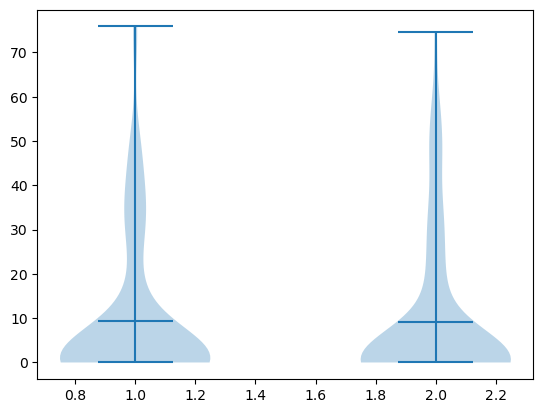

In [119]:
plt.violinplot([error_test, error_control_test], showmeans=True)

In [120]:
wilco_test  = wilcoxon(error_test, error_control_test, alternative='less')
t_test = ttest_ind(error_test, error_control_test, alternative='less')

wilco_test.pvalue < 0.05, t_test.pvalue < 0.05

(np.False_, np.False_)

{'bodies': [<matplotlib.collections.PolyCollection at 0x7f5d76b7aa50>,
 'cmeans': <matplotlib.collections.LineCollection at 0x7f5d76b61250>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f5d76b39110>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f5d75f12510>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f5d76b92f10>}

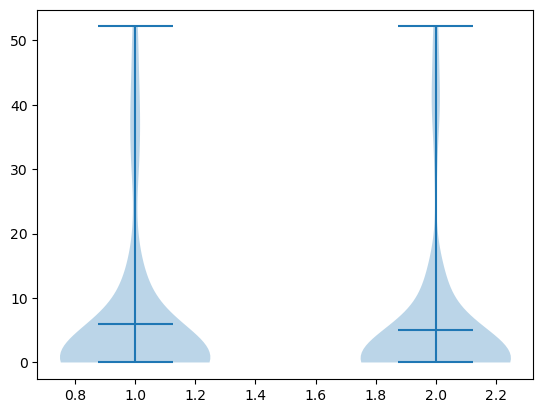

In [121]:
plt.violinplot([error_train, error_zeros_train], showmeans=True)

In [122]:
wilco_train = wilcoxon(error_train, error_zeros_train, alternative='less')
t_train     = ttest_ind(error_train, error_zeros_train, alternative='less')

wilco_train.pvalue < 0.05, t_train.pvalue < 0.05

(np.True_, np.False_)

{'bodies': [<matplotlib.collections.PolyCollection at 0x7f5d75f58510>,
 'cmeans': <matplotlib.collections.LineCollection at 0x7f5d75f60310>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f5d75f8b290>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f5d75f90650>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f5d75f31990>}

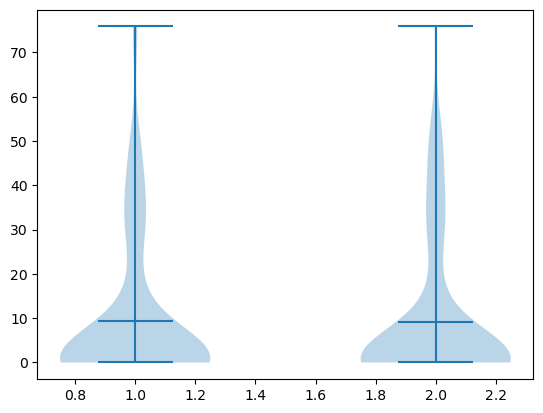

In [123]:
plt.violinplot([error_test, error_zeros_test], showmeans=True)

In [124]:
wilco_train = wilcoxon(error_test, error_zeros_test, alternative='less')
t_train     = ttest_ind(error_test, error_zeros_test, alternative='less')

wilco_train.pvalue < 0.05, t_train.pvalue < 0.05

(np.True_, np.False_)